<a href="https://colab.research.google.com/github/kcf1/fina4359-quant-trading/blob/asm1/fina4359_asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pandas_datareader as pdr

# Import macro return data

In [121]:
ret = pd.read_excel('macro_return.xlsx',index_col=0,parse_dates=True)

In [122]:
ret = ret.iloc[18:302,1].astype(float)


Samples 284 months

Annulized
Mean = 17.93%
Std  = 13.35%
Skew = -0.02
SR   = 1.34



<Axes: >

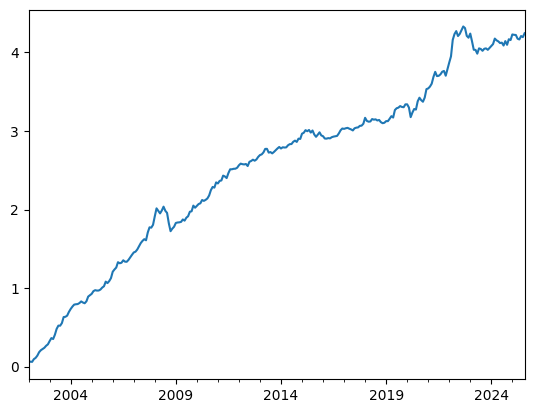

In [123]:
m = ret.mean() * 12
s = ret.std() * 12 ** 0.5
sr = m/s
sk = ret.skew()
print(f'''
Samples {ret.count()} months

Annulized
Mean = {m:.2%}
Std  = {s:.2%}
Skew = {sk:.2f}
SR   = {sr:.2f}
''')
ret.cumsum().plot()

# FF5 Benchmark
Conceptually, not a good benchmark:
- Macro invests in all asset classes (incl. fx, rates, commods, etc.) across regions, while FF5 only covers US equity factors
- FF5 might explain partially, as US equities is in fund's investment universe
---
Reasonable benchmark (alpha on FF5 adds uncorrelated return to their portfolio):
- US pension that primarily invest in US equity
- US big corp that are sensitive to US market cycles (high beta)
---
Inappropriate benchmark:
- Relative performance to macro peers
- Investors with access to global markets (not only US)

In [124]:
import pandas_datareader as pdr
# Fama-French 5 factors (2x3). Returns a list; [0] is the factor returns.
ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]

/tmp/ipython-input-1227/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]
/tmp/ipython-input-1227/1621005415.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start='2000-01', end=None)[0]


In [125]:
ff5 = ff5 / 100
ff5.index = ff5.index.to_timestamp() + pd.offsets.MonthEnd(0)

In [127]:
reg_df = ff5.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [128]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

As expected, not a good benchmark:
- FF5 factors did not explained much of the return, resulting in significantly high alpha
- Only US market factor is significant, beta ~0.24, except that HML has a relative small p-value (still insignificant), fund might have some value play
- R^2 is only 10% (90% left unexplained), FF5 failed to track the index properly

In [129]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 13.88%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     6.360
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.31e-05
Time:                        11:19:54   Log-Likelihood:                 536.60
No. Observations:                 284   AIC:                            -1061.
Df Residuals:                     278   BIC:                            -1039.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0116      0.002      5.053      0.000       0.007       0.016
Mkt-RF         0.2398      0.055      4.386      0.000       0.132       0.347
SMB           -0.0020      0.095     -0.021      0.983      -0.189       0.185
HML            0.1310      0.092      1.417      0.158      -0.051       0.313
RMW            0.0185      0.113      0.164      0.870      -0.204       0.241
CMA            0.1576      0.138      1.145      0.253      -0.113       0.429
==============================================================================
Omnibus:                       29.932   Durbin-Watson:                   1.620
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              126.857
Skew:                           0.246   Prob(JB):                     2.84e-28
Kurtosis:                       6.237   Cond. No.                         69.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Custom benchmark
Candidate factors:
- Momentum / Trend
- Carry
- Value
- Equity
- Rates
- Credit
- Volatility?
- Cycle
- DM vs EM Equity
- Risk On / Off

In [334]:
import yfinance as yf
import seaborn as sns

In [1032]:
new = yf.download(['^VIX'],period='max',interval='1d')['Close']
new_ret = new.resample('me').last().pct_change()
new_ret.dropna(inplace=True)

/tmp/ipython-input-1227/563464497.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  new = yf.download(['^VIX'],period='max',interval='1d')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1227/563464497.py:2: FutureWarning: 'me' is deprecated and will be removed in a future version, please use 'ME' instead.
  new_ret = new.resample('me').last().pct_change()


In [1033]:
new_ret.head()

Ticker,^VIX
Date,
1990-02-28,-0.132886
1990-03-31,-0.102774
1990-04-30,-0.010644
1990-05-31,-0.110143
1990-06-30,-0.107657


In [1034]:
jkp_ret = pd.read_csv('jkp_factors.csv')
jkp_ret[['location','name','ret']].groupby(['name','location']).count().unstack()

ret                                    
location            developed emerging frontier world world_ex_us
name                                                             
accruals                  468      380      104   948         468
debt_issuance             468      380      207   878         468
investment                468      407      208  1128         468
low_leverage              468      439      214  1187         468
low_risk                  468      443      214  1187         468
momentum                  465      441      214  1185         465
profit_growth             468      435      208  1176         468
profitability             468      392      214  1185         468
quality                   468      434      214  1176         468
seasonality               468      438      213  1187         468
short_term_reversal       467      445      214  1187         467
size                      468      446      214  1188         468
value                     468      435      210  1177         468

In [1093]:
jkp_ret = pd.read_csv('jkp_factors.csv')
jkp_ret['long_name'] = jkp_ret['location'] + '_' + jkp_ret['name']
#jkp_ret = jkp_ret[jkp_ret['location']=='frontier']
jkp_ret = jkp_ret[['date','long_name','ret']]
jkp_ret = jkp_ret.set_index(['date','long_name']).unstack()
jkp_ret = jkp_ret.droplevel(axis=1,level=0)
jkp_ret.index = pd.to_datetime(jkp_ret.index)
jkp_ret = jkp_ret[['emerging_momentum','world_value']]
#jkp_ret = jkp_ret[['frontier_investment','developed_value','emerging_momentum']]

In [1174]:
factors = pd.read_excel('candidate_factors.xlsx')
factors.index = factors.iloc[:,0]
factors.index.name = 'Date'
factors = factors.iloc[:,[1,5]]

In [1187]:
#fret = jkp_ret.copy()
#fret = tsm_ret.copy()
fret = factors.pct_change()
#fret['Mkt-RF'] = ff5['Mkt-RF']
fret['RF'] = ff5['RF']
fret = pd.concat([fret,jkp_ret],axis=1)
fret.dropna(inplace=True)

In [1188]:
#fret = fret.loc['2006':]

<Axes: >

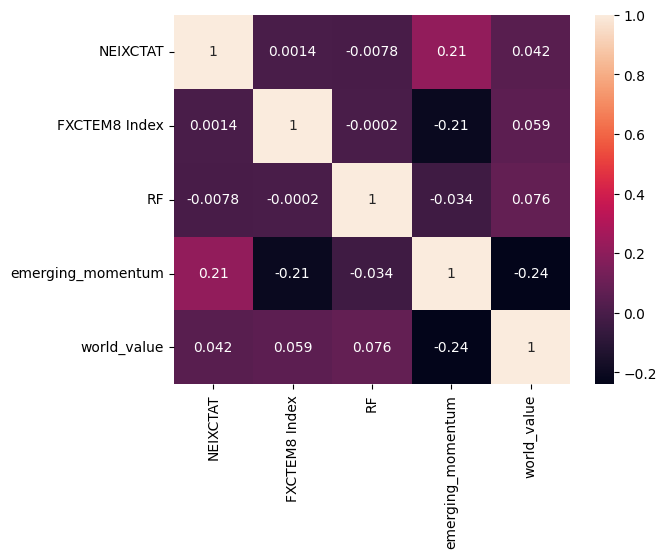

In [1189]:
sns.heatmap(fret.corr(),annot=True)

In [1190]:
reg_df = fret.copy()
reg_df['Macro-RF'] = ret - reg_df['RF']
reg_df.dropna(inplace=True)

In [1191]:
y = reg_df['Macro-RF']
x = reg_df.drop(columns=['RF','Macro-RF'])

In [1192]:
model = sm.OLS(y,sm.add_constant(x)).fit()
alpha = model.params['const'] * 12
print(f'Ann. alpha = {alpha:.2%}')
model.summary()

Ann. alpha = 6.58%


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Macro-RF   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     29.81
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.72e-19
Time:                        13:25:16   Log-Likelihood:                 394.05
No. Observations:                 197   AIC:                            -778.1
Df Residuals:                     192   BIC:                            -761.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0055      0.003      2.165      0.032       0.000       0.010
NEIXCTAT              0.4780      0.066      7.205      0.000       0.347       0.609
FXCTEM8 Index         0.5726      0.086      6.687      0.000       0.404       0.741
emerging_momentum     0.4276      0.145      2.944      0.004       0.141       0.714
world_value           0.4532      0.148      3.068      0.002       0.162       0.745
==============================================================================
Omnibus:                       18.444   Durbin-Watson:                   1.599
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.280
Skew:                          -0.214   Prob(JB):                     1.34e-13
Kurtosis:                       5.653   Cond. No.                         73.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1091]:
res = y - model.predict(sm.add_constant(x))

<Axes: >

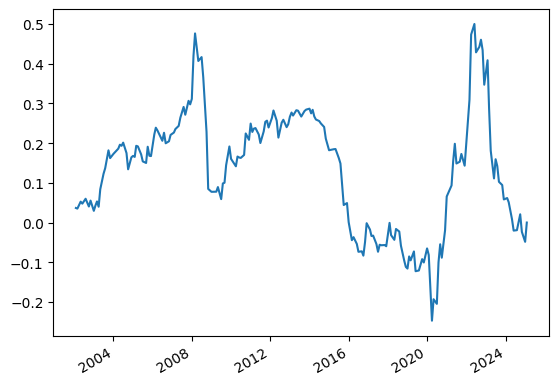

In [1092]:
res.cumsum().plot()